# Records over time

This notebook plots the number of records in our database over time.

In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt

with open("../resources/scadsai.yml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

resources = data["resources"]

# When records were published

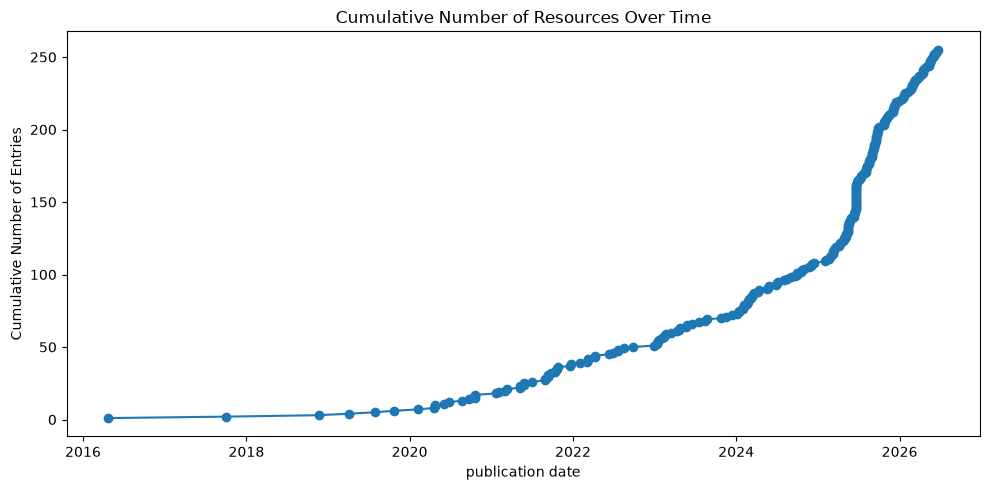

In [2]:
dates = [entry["publication_date"] for entry in resources]

df = pd.DataFrame({"publication_date": pd.to_datetime(dates, format='mixed', utc=True)})
df = df.sort_values("publication_date")
df["count"] = range(1, len(df) + 1)

plt.figure(figsize=(10, 5))
plt.plot(df["publication_date"], df["count"], marker="o")
plt.xlabel("publication date")
plt.ylabel("Cumulative Number of Entries")
plt.title("Cumulative Number of Resources Over Time")
plt.tight_layout()
plt.show()

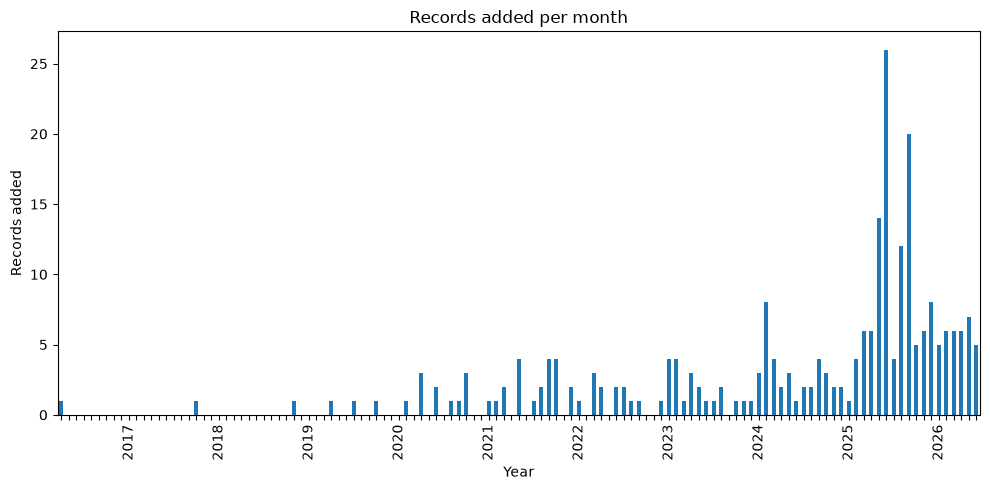

In [9]:
# Ensure datetime and sorted
df["publication_date"] = pd.to_datetime(df["publication_date"])
df_sorted = df.sort_values("publication_date")

# Resample by month, taking the last cumulative count of each month
monthly_counts = df_sorted.set_index("publication_date")["count"].resample("ME").last().ffill()

# Compute derivative (records added per month)
records_added = monthly_counts.diff().fillna(monthly_counts.iloc[0])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
records_added.plot(kind="bar", ax=ax)
ax.set_xlabel("Year")
ax.set_ylabel("Records added")
ax.set_title("Records added per month")

# Show only year labels on x-axis (one tick per year, at January)
tick_labels = [d.strftime("%Y") if d.month == 1 else "" for d in records_added.index]
ax.set_xticklabels(tick_labels)

plt.tight_layout()
plt.show()

# When records were added to our database

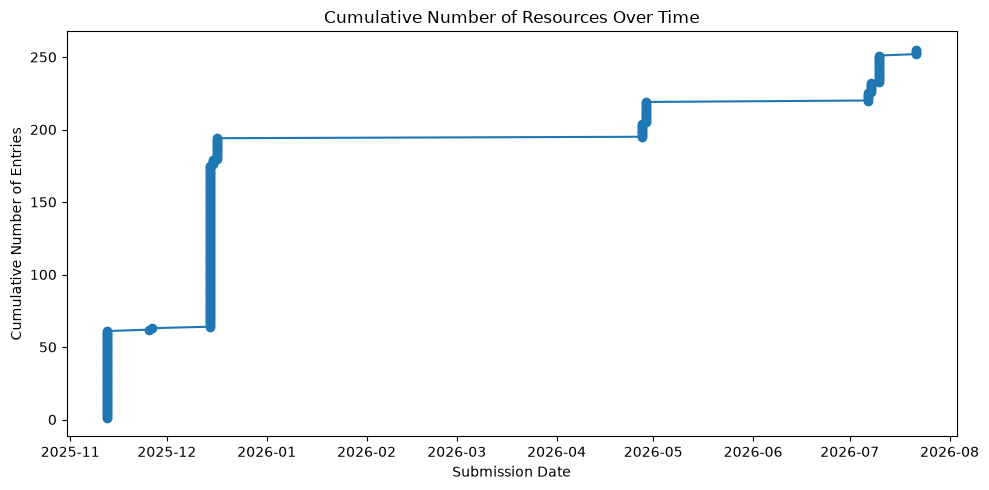

In [10]:
dates = [entry["submission_date"] for entry in resources]

df = pd.DataFrame({"submission_date": pd.to_datetime(dates)})
df = df.sort_values("submission_date")
df["count"] = range(1, len(df) + 1)

plt.figure(figsize=(10, 5))
plt.plot(df["submission_date"], df["count"], marker="o")
plt.xlabel("Submission Date")
plt.ylabel("Cumulative Number of Entries")
plt.title("Cumulative Number of Resources Over Time")
plt.tight_layout()
plt.show()